Dataset loaded successfully.

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220320 entries, 0 to 220319
Data columns (total 55 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Unnamed: 0      220320 non-null  int64  
 1   timestamp       220320 non-null  object 
 2   sensor_00       210112 non-null  float64
 3   sensor_01       219951 non-null  float64
 4   sensor_02       220301 non-null  float64
 5   sensor_03       220301 non-null  float64
 6   sensor_04       220301 non-null  float64
 7   sensor_05       220301 non-null  float64
 8   sensor_06       215522 non-null  float64
 9   sensor_07       214869 non-null  float64
 10  sensor_08       215213 non-null  float64
 11  sensor_09       215725 non-null  float64
 12  sensor_10       220301 non-null  float64
 13  sensor_11       220301 non-null  float64
 14  sensor_12       220301 non-null  float64
 15  sensor_13       220301 non-null  float64
 16  senso

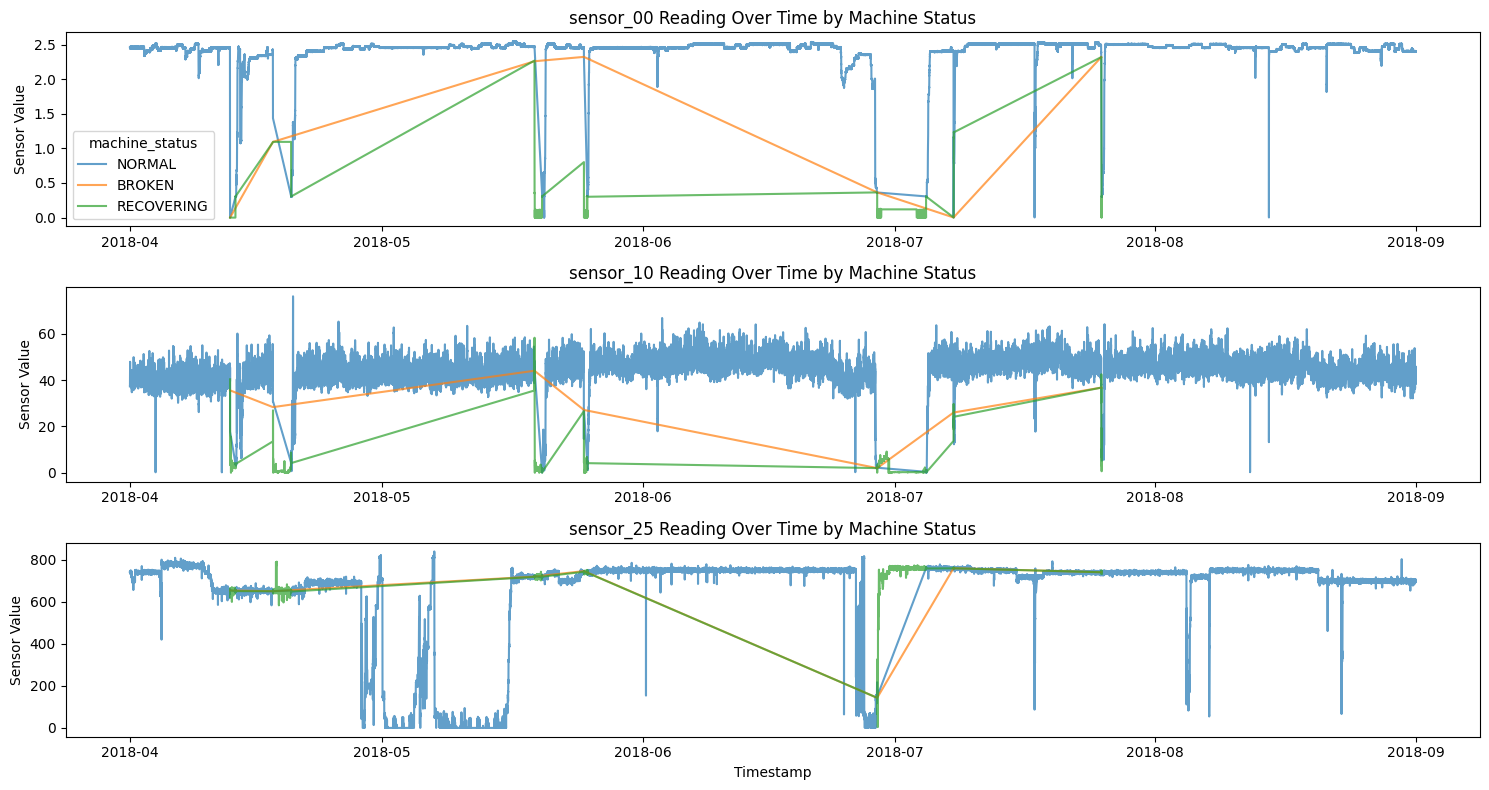

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
dataset_path = r"C:\Users\THILAK R\Downloads\AI Engineer Assignment\AI Engineer Assignment\sensor.csv"
try:
    df = pd.read_csv(dataset_path)
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print("Error: sensor.csv not found. Please make sure the file is in the correct directory.")
    # Exit or handle error appropriately
    exit()

# --- Initial Exploration ---

print("\n--- Dataset Info ---")
df.info()
# Note: The info() output will show column names, non-null counts, and data types.
# The first column seems unnamed (index) and timestamp shows '#######' in the image,
# likely due to display width, but pandas should read it if formatted correctly.

print("\n--- First 5 Rows ---")
print(df.head())

print("\n--- Basic Statistics ---")
# Include 'all' to get stats for object columns too (like machine_status)
print(df.describe(include='all'))

# --- Preprocessing Steps ---

# 1. Handle potential unnamed index column
# Check if the first column is unnamed and looks like an index
if df.columns[0].startswith('Unnamed'):
    print(f"\nDropping unnamed index column: {df.columns[0]}")
    df = df.drop(columns=[df.columns[0]])
    # Alternatively, if it was meant to be the index during saving:
    # df = pd.read_csv('sensor.csv', index_col=0)

# 2. Handle Timestamp
# Assuming the 'timestamp' column exists and needs conversion
if 'timestamp' in df.columns:
    print("\nConverting 'timestamp' column to datetime objects...")
    try:
        # Pandas might interpret '##...' as NaT or raise an error if format is unexpected.
        # Let's try inferring the format first. If it fails, specify common formats.
        df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce') # Coerce forces unparseable to NaT
        
        # Check if conversion resulted in NaT (Not a Time) values
        if df['timestamp'].isnull().any():
            print("Warning: Some timestamp values could not be parsed and are set to NaT.")
            # Optional: Try specific formats if infer_datetime_format fails
            # df['timestamp'] = pd.to_datetime(df['timestamp'], format='%Y-%m-%d %H:%M:%S', errors='coerce')
            
        # Optional: Set timestamp as index for time-series analysis
        # df = df.set_index('timestamp')
        # df = df.sort_index() # Ensure chronological order if setting as index
        
    except Exception as e:
        print(f"Error converting timestamp: {e}. Check the format in the CSV.")
        # If timestamp is crucial and fails, might need manual inspection/cleaning
else:
    print("Warning: 'timestamp' column not found.")


# 3. Handle Missing Values (NaN)
print("\n--- Missing Values Check ---")
missing_values = df.isnull().sum()
print("Columns with missing values:")
print(missing_values[missing_values > 0])

# Strategy: Imputation for sensor readings. Given it's time-series data,
# forward fill ('ffill') is often a good starting point, assuming readings
# don't change drastically between short intervals.
# Let's identify numeric columns first (excluding timestamp if it's still a column)
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

if missing_values.sum() > 0:
    print(f"\nTotal missing values before imputation: {missing_values.sum()}")
    print("Applying forward fill (ffill) to numeric columns...")
    df[numeric_cols] = df[numeric_cols].ffill()
    # Optional: Apply backward fill ('bfill') afterwards to catch NaNs at the start
    df[numeric_cols] = df[numeric_cols].bfill()
    
    print(f"Total missing values after imputation: {df.isnull().sum().sum()}")
    # If any NaNs remain (e.g., entire column was NaN or in non-numeric cols), decide further action.
    if df.isnull().sum().sum() > 0:
         print("Warning: Missing values still present after ffill/bfill. Consider dropping columns/rows or using other imputation methods (e.g., mean/median).")
         # Example: Drop columns with a high percentage of missing values
         # threshold = 0.5 # Drop columns with > 50% missing
         # df = df.dropna(axis=1, thresh=int(threshold * len(df)))
         # Example: Drop rows with any remaining NaNs (use cautiously)
         # df = df.dropna()


# 4. Check for Duplicates (especially after handling timestamp/index)
duplicates = df.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicates}")
if duplicates > 0:
    print("Dropping duplicate rows...")
    df = df.drop_duplicates()
    print(f"Dataset shape after dropping duplicates: {df.shape}")

# 5. Target Variable Analysis
print("\n--- Target Variable Distribution ('machine_status') ---")
target_counts = df['machine_status'].value_counts()
print(target_counts)

# --- Deliverable: Summary and Visualization ---

print("\n--- Data Exploration & Preprocessing Summary ---")
print(f"Dataset Shape: {df.shape}")
print(f"Data Types:\n{df.dtypes.value_counts()}") # Summary of data types
print(f"Missing Values: {df.isnull().sum().sum()} (after imputation/handling)")
print("Target Variable ('machine_status') Distribution:")
print(target_counts)
if 'timestamp' in df.columns and pd.api.types.is_datetime64_any_dtype(df['timestamp']):
    print(f"Time range: {df['timestamp'].min()} to {df['timestamp'].max()}")
elif isinstance(df.index, pd.DatetimeIndex):
     print(f"Time range: {df.index.min()} to {df.index.max()}")

# Visualization: Plot a few sensor readings over time, colored by machine_status
print("\nGenerating sensor plot visualization...")
plt.figure(figsize=(15, 8))

# Select a few sensors to plot (e.g., sensor_00, sensor_10, sensor_25)
sensors_to_plot = ['sensor_00', 'sensor_10', 'sensor_25']

# Create subplots
for i, sensor in enumerate(sensors_to_plot):
    if sensor in df.columns:
        plt.subplot(len(sensors_to_plot), 1, i+1)
        # Use timestamp if available and correctly parsed, otherwise use numerical index
        x_axis = df['timestamp'] if 'timestamp' in df.columns and pd.api.types.is_datetime64_any_dtype(df['timestamp']) else df.index
        sns.lineplot(x=x_axis, y=df[sensor], hue=df['machine_status'], legend=(i==0), alpha=0.7) # Show legend only on first plot
        plt.title(f'{sensor} Reading Over Time by Machine Status')
        plt.ylabel('Sensor Value')
        if i < len(sensors_to_plot) - 1:
            plt.xlabel('') # Remove x-label for upper plots
        else:
             plt.xlabel('Timestamp' if 'timestamp' in df.columns and pd.api.types.is_datetime64_any_dtype(df['timestamp']) else 'Index')


plt.tight_layout()
plt.savefig("sensor_readings_over_time.png") # Save the plot
print("Visualization saved as 'sensor_readings_over_time.png'")
# plt.show() # Uncomment to display the plot directly if running interactively

In [3]:
# (Assuming 'df' is the DataFrame after the previous steps)

# Drop the entirely empty sensor_15 column
if 'sensor_15' in df.columns:
    print("\nDropping column 'sensor_15' due to all missing values...")
    df = df.drop(columns=['sensor_15'])
    print("Column 'sensor_15' dropped.")
    # Verify missing values again
    print(f"Total missing values after dropping sensor_15: {df.isnull().sum().sum()}") # Should be 0 now

# Handle the 'BROKEN' status
broken_count = (df['machine_status'] == 'BROKEN').sum()
print(f"\nHandling the '{broken_count}' instances of 'BROKEN' status.")

# Strategy: Combine 'BROKEN' with 'RECOVERING' as it's rare and likely represents a non-normal state.
# Alternatively, could drop these rows: df = df[df['machine_status'] != 'BROKEN']
if broken_count > 0:
    print("Mapping 'BROKEN' status to 'RECOVERING'.")
    df['machine_status'] = df['machine_status'].replace('BROKEN', 'RECOVERING')
    print("\nNew Target Variable Distribution:")
    print(df['machine_status'].value_counts())
    # Now it should be a binary classification problem: NORMAL vs RECOVERING

# Optional: Encode the target variable (NORMAL=0, RECOVERING=1)
print("\nEncoding 'machine_status' to numerical format (NORMAL=0, RECOVERING=1)...")
df['status_encoded'] = df['machine_status'].map({'NORMAL': 0, 'RECOVERING': 1})
# Keep the original 'machine_status' for reference if needed, drop later before modeling if preferred.
# Or replace directly: df['machine_status'] = df['machine_status'].map({'NORMAL': 0, 'RECOVERING': 1})

# Separate features (X) and target (y)
sensor_columns = [col for col in df.columns if col.startswith('sensor_')]
if 'timestamp' in df.columns and pd.api.types.is_datetime64_any_dtype(df['timestamp']):
    features_df = df[sensor_columns + ['timestamp']] # Keep timestamp for time-based features
else:
    features_df = df[sensor_columns]

target_series = df['status_encoded'] # Use the encoded target

print(f"\nShape of features_df: {features_df.shape}")
print(f"Shape of target_series: {target_series.shape}")


Dropping column 'sensor_15' due to all missing values...
Column 'sensor_15' dropped.
Total missing values after dropping sensor_15: 0

Handling the '7' instances of 'BROKEN' status.
Mapping 'BROKEN' status to 'RECOVERING'.

New Target Variable Distribution:
machine_status
NORMAL        205836
RECOVERING     14484
Name: count, dtype: int64

Encoding 'machine_status' to numerical format (NORMAL=0, RECOVERING=1)...

Shape of features_df: (220320, 52)
Shape of target_series: (220320,)


In [5]:
# (Continuing from the refined preprocessing code)

# Define the window size (e.g., 10 periods, assuming 1-minute intervals = 10 minutes)
window_size = 10

# Calculate rolling mean and std deviation for all sensor columns
print(f"\nCalculating rolling mean and std dev with window size {window_size}...")
for col in sensor_columns:
    # Ensure column is numeric before applying rolling operations
    if pd.api.types.is_numeric_dtype(features_df[col]):
        features_df[f'{col}_roll_mean_{window_size}'] = features_df[col].rolling(window=window_size, min_periods=1).mean()
        features_df[f'{col}_roll_std_{window_size}'] = features_df[col].rolling(window=window_size, min_periods=1).std()
    else:
         print(f"Skipping non-numeric column for rolling features: {col}")


# The initial rows will have NaN for std dev until the window is full.
# Also, rolling calculations might introduce NaNs if the original data had them near the start.
# Let's back-fill these NaNs resulting from the rolling calculation.
print("\nHandling NaNs introduced by rolling calculations (using bfill)...")
features_df = features_df.fillna(method='bfill')

# Drop the original sensor columns? Optional, but often done to avoid multicollinearity
# If kept, the model might use both instantaneous and rolling features. Let's keep them for now.
# features_df = features_df.drop(columns=sensor_columns)


# --- Deliverable: List of Features with Justifications ---

print("\n--- Engineered Features List ---")
engineered_features = [col for col in features_df.columns if col.startswith('sensor_') and ('roll_mean' in col or 'roll_std' in col)]

print("1. Rolling Mean Features (e.g., sensor_XX_roll_mean_10):")
print("   - Calculation: Mean value of each sensor over the last 10 data points (minutes).")
print("   - Justification: Captures the recent central tendency of the sensor reading, smoothing out short-term noise and highlighting shifts in the baseline level. Changes in rolling mean can indicate gradual drift or operational mode changes preceding failure or recovery.")

print("\n2. Rolling Standard Deviation Features (e.g., sensor_XX_roll_std_10):")
print("   - Calculation: Standard deviation of each sensor over the last 10 data points (minutes).")
print("   - Justification: Measures the recent volatility or stability of the sensor reading. An increase in rolling standard deviation can signal erratic behavior, increased vibration, or instability, which are often precursors to pump issues.")

# We also retain the original sensor readings:
print("\n3. Original Sensor Readings (sensor_XX):")
print("   - Calculation: Instantaneous value of the sensor at each timestamp.")
print("   - Justification: Provides the most current state information. While potentially noisy, sharp spikes or drops in the raw data can be direct indicators of immediate events or anomalies that rolling features might smooth over.")

# We are NOT explicitly adding lag features here, but rolling features implicitly use past data.
# We are NOT adding time-based features from timestamp yet, but could be added if needed.
# We are NOT adding interaction features yet.

# Keep only feature columns (drop timestamp if it's still there and not needed further)
if 'timestamp' in features_df.columns:
     features_df = features_df.drop(columns=['timestamp'])
     
final_feature_list = features_df.columns.tolist()
print(f"\nTotal number of features for modeling: {len(final_feature_list)}")
print("Example feature names:", final_feature_list[:5], "...", final_feature_list[-5:])

# Prepare final X and y for modeling
X = features_df
y = target_series # Already defined earlier

# Check shapes again
print(f"\nFinal shape of X: {X.shape}")
print(f"Final shape of y: {y.shape}")

# Ensure X contains no NaN values before modeling
if X.isnull().sum().sum() > 0:
    print("\nWarning: NaNs detected in final feature set X. Check imputation steps.")
    # Force fill any remaining NaNs (e.g., with 0 or median/mean of column) - use cautiously
    # X = X.fillna(0) 
    # Or investigate why NaNs persist
else:
    print("\nNo NaNs detected in the final feature set X.")


Calculating rolling mean and std dev with window size 10...


C:\Users\THILAK R\AppData\Local\Temp\ipykernel_3876\2320573413.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  features_df[f'{col}_roll_mean_{window_size}'] = features_df[col].rolling(window=window_size, min_periods=1).mean()
C:\Users\THILAK R\AppData\Local\Temp\ipykernel_3876\2320573413.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  features_df[f'{col}_roll_mean_{window_size}'] = features_df[col].rolling(window=window_size, min_periods=1).mean()
C:\Users\THILAK R\AppData\Local\Temp\ipykernel_3876\232057341


Handling NaNs introduced by rolling calculations (using bfill)...

--- Engineered Features List ---
1. Rolling Mean Features (e.g., sensor_XX_roll_mean_10):
   - Calculation: Mean value of each sensor over the last 10 data points (minutes).
   - Justification: Captures the recent central tendency of the sensor reading, smoothing out short-term noise and highlighting shifts in the baseline level. Changes in rolling mean can indicate gradual drift or operational mode changes preceding failure or recovery.

2. Rolling Standard Deviation Features (e.g., sensor_XX_roll_std_10):
   - Calculation: Standard deviation of each sensor over the last 10 data points (minutes).
   - Justification: Measures the recent volatility or stability of the sensor reading. An increase in rolling standard deviation can signal erratic behavior, increased vibration, or instability, which are often precursors to pump issues.

3. Original Sensor Readings (sensor_XX):
   - Calculation: Instantaneous value of the se

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier # Added KNN
from lightgbm import LGBMClassifier # Added LightGBM
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    precision_recall_curve, auc, accuracy_score,
    precision_score, recall_score, f1_score, RocCurveDisplay, PrecisionRecallDisplay
)
import time
import joblib
import os # For creating directories

# --- Create Output Directory ---
output_dir = "model_results"
os.makedirs(output_dir, exist_ok=True)
print(f"Created output directory: {output_dir}")

# Assuming X and y are the final feature DataFrame and target Series from Phase 2

# --- Data Splitting (Stratified Shuffle Split) ---
print("\n--- Data Splitting (Stratified Shuffle Split) ---")
print("Warning: Using stratified shuffle split. This ensures class balance in train/test")
print("         but breaks strict chronological order, potentially inflating results.")

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,    # Keep 20% for testing
    random_state=42,   # For reproducibility
    stratify=y,        # Ensure class proportions are maintained
    shuffle=True       # Stratify requires shuffling
)

print(f"Training set shape: X={X_train.shape}, y={y_train.shape}")
print(f"Testing set shape:  X={X_test.shape}, y={y_test.shape}")
print(f"Training target distribution:\n{y_train.value_counts(normalize=True)}")
print(f"Testing target distribution:\n{y_test.value_counts(normalize=True)}") # Should now have both classes

# --- Feature Scaling ---
print("\n--- Feature Scaling ---")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) # Use transform, not fit_transform!

# Save the scaler
scaler_path = os.path.join(output_dir, 'scaler.pkl')
joblib.dump(scaler, scaler_path)
print(f"Scaler saved to {scaler_path}")

print("Scaling complete.")

# --- Model Selection and Training ---

# Define models
# Added LightGBM and KNN
models = {
    "Logistic Regression": LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000, solver='liblinear'),
    "Random Forest": RandomForestClassifier(class_weight='balanced', random_state=42, n_estimators=100, n_jobs=-1),
    "LightGBM": LGBMClassifier(is_unbalance=True, random_state=42, n_jobs=-1), # Handles imbalance internally
    "KNN (k=5)": KNeighborsClassifier(n_neighbors=5, n_jobs=-1) # KNN doesn't directly take class_weight
}

results = {} # To store model performance
trained_models = {} # To store trained model objects

print("\n--- Model Training and Evaluation ---")

for name, model in models.items():
    print(f"\n--- Training and Evaluating {name} ---")
    start_time = time.time()

    # Train the model
    model.fit(X_train_scaled, y_train)
    trained_models[name] = model # Store the trained model object

    train_time = time.time() - start_time
    print(f"Training completed in {train_time:.2f} seconds.")

    # Predict on test data
    start_time = time.time()
    y_pred = model.predict(X_test_scaled)
    # Get probabilities for the positive class (needed for AUC scores)
    # Handle KNN which doesn't have predict_proba quite the same way if needed, but usually fine
    try:
        y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    except AttributeError:
        print(f"Warning: {name} does not have predict_proba. ROC/PR AUC might be inaccurate.")
        # Use decision_function or other methods if available, or skip AUCs for this model
        y_pred_proba = y_pred # Placeholder, won't give meaningful AUC

    eval_time = time.time() - start_time
    print(f"Evaluation completed in {eval_time:.2f} seconds.")

    # Calculate Metrics (focus on class 1: RECOVERING)
    # Use labels=[0, 1] to ensure metrics are calculated for both, even if predictions are skewed
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, pos_label=1, zero_division=0, labels=[0,1])
    recall = recall_score(y_test, y_pred, pos_label=1, zero_division=0, labels=[0,1])
    f1 = f1_score(y_test, y_pred, pos_label=1, zero_division=0, labels=[0,1])

    # Calculate AUC scores (handle cases where predict_proba might not be suitable)
    try:
        roc_auc = roc_auc_score(y_test, y_pred_proba)
        pr_precision_curve, pr_recall_curve, _ = precision_recall_curve(y_test, y_pred_proba, pos_label=1)
        pr_auc = auc(pr_recall_curve, pr_precision_curve)
    except ValueError as e:
        print(f"Warning: Could not calculate AUC scores for {name}. Error: {e}")
        roc_auc = np.nan
        pr_auc = np.nan


    # Store results
    results[name] = {
        "Accuracy": accuracy,
        "Precision (Class 1)": precision,
        "Recall (Class 1)": recall,
        "F1-Score (Class 1)": f1,
        "ROC AUC": roc_auc,
        "PR AUC": pr_auc,
        "Training Time (s)": train_time,
        "Evaluation Time (s)": eval_time
    }

    # --- Reporting and Plotting ---
    print(f"\n--- Results for {name} ---")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"ROC AUC: {roc_auc:.4f}")
    print(f"PR AUC: {pr_auc:.4f}")

    print("\nClassification Report (Test Set):")
    # Specify labels=[0, 1] and target_names to ensure correct report structure
    print(classification_report(y_test, y_pred, labels=[0, 1], target_names=['NORMAL (0)', 'RECOVERING (1)'], zero_division=0))

    print("\nConfusion Matrix (Test Set):")
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
    print(cm)

    # Plot and save Confusion Matrix
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['NORMAL (0)', 'RECOVERING (1)'], yticklabels=['NORMAL (0)', 'RECOVERING (1)'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'Confusion Matrix - {name}')
    cm_path = os.path.join(output_dir, f'{name.replace(" ", "_").lower()}_confusion_matrix.png')
    plt.savefig(cm_path)
    print(f"Confusion matrix plot saved to {cm_path}")
    plt.close() # Close the plot figure


    # Plot and save ROC Curve (if possible)
    if not np.isnan(roc_auc):
      try:
          plt.figure(figsize=(6, 6))
          RocCurveDisplay.from_estimator(model, X_test_scaled, y_test, name=name)
          plt.plot([0, 1], [0, 1], 'k--', label='Chance level (AUC = 0.5)')
          plt.title(f'ROC Curve - {name}')
          plt.legend()
          roc_path = os.path.join(output_dir, f'{name.replace(" ", "_").lower()}_roc_curve.png')
          plt.savefig(roc_path)
          print(f"ROC curve plot saved to {roc_path}")
          plt.close()
      except Exception as e:
          print(f"Could not plot ROC curve for {name}: {e}")


    # Plot and save Precision-Recall Curve (if possible)
    if not np.isnan(pr_auc):
      try:
          plt.figure(figsize=(6, 6))
          PrecisionRecallDisplay.from_estimator(model, X_test_scaled, y_test, name=name)
          plt.title(f'Precision-Recall Curve - {name}')
          pr_path = os.path.join(output_dir, f'{name.replace(" ", "_").lower()}_pr_curve.png')
          plt.savefig(pr_path)
          print(f"PR curve plot saved to {pr_path}")
          plt.close()
      except Exception as e:
           print(f"Could not plot PR curve for {name}: {e}")


# --- Model Comparison ---
print("\n--- Model Comparison Summary ---")
results_df = pd.DataFrame(results).T # Transpose for better readability
print(results_df.round(4))

# Save results summary to CSV
results_csv_path = os.path.join(output_dir, 'model_comparison_summary.csv')
results_df.to_csv(results_csv_path)
print(f"Results summary saved to {results_csv_path}")


# --- Best Model Discussion ---
print("\n--- Best Model Discussion ---")

# Determine best model based on PR AUC (good for imbalance)
# Handle potential NaN values in PR AUC when selecting best model
valid_results = results_df.dropna(subset=['PR AUC'])
if not valid_results.empty:
    best_model_name = valid_results['PR AUC'].idxmax()
    best_pr_auc = valid_results.loc[best_model_name, 'PR AUC']

    print(f"Based on the Precision-Recall AUC (PR AUC), the best performing model is: **{best_model_name}**")
    print(f"It achieved a PR AUC of {best_pr_auc:.4f}.")

    best_f1 = results_df.loc[best_model_name, 'F1-Score (Class 1)']
    best_recall = results_df.loc[best_model_name, 'Recall (Class 1)']
    best_precision = results_df.loc[best_model_name, 'Precision (Class 1)']
    best_roc_auc = results_df.loc[best_model_name, 'ROC AUC']

    print(f"\nKey metrics for {best_model_name}:")
    print(f" - F1-Score (Recovering): {best_f1:.4f}")
    print(f" - Recall (Recovering): {best_recall:.4f}")
    print(f" - Precision (Recovering): {best_precision:.4f}")
    print(f" - ROC AUC: {best_roc_auc:.4f}")

    print("\nDiscussion:")
    # Add discussion comparing models based on results_df...
    print(f"The goal is to detect 'RECOVERING' states (high Recall) without too many false alarms (good Precision).")
    print(f"{best_model_name} provides the best balance judged by PR AUC.")
    print("Compare its Recall and Precision to other models in the table above.")
    # Example comparison point:
    # other_good_model = valid_results.sort_values('PR AUC', ascending=False).index[1] # Second best
    # print(f"Compared to {other_good_model}, {best_model_name} shows [mention specific advantage, e.g., higher recall].")


    print(f"\nTherefore, {best_model_name} is recommended for deployment based on these results.")

    # Save the best model object
    best_model_object = trained_models[best_model_name]
    model_save_path = os.path.join(output_dir, f'{best_model_name.replace(" ", "_").lower()}_best_model.pkl')
    joblib.dump(best_model_object, model_save_path)
    print(f"\nBest model ({best_model_name}) saved to {model_save_path}")

else:
    print("\nError: Could not determine best model because PR AUC calculation failed for all models.")
    print("Please check warnings during evaluation for reasons (e.g., predict_proba issues).")

Created output directory: model_results

--- Data Splitting (Stratified Shuffle Split) ---
         but breaks strict chronological order, potentially inflating results.
Training set shape: X=(176256, 153), y=(176256,)
Testing set shape:  X=(44064, 153), y=(44064,)
Training target distribution:
status_encoded
0    0.93426
1    0.06574
Name: proportion, dtype: float64
Testing target distribution:
status_encoded
0    0.934255
1    0.065745
Name: proportion, dtype: float64

--- Feature Scaling ---
Scaler saved to model_results\scaler.pkl
Scaling complete.

--- Model Training and Evaluation ---

--- Training and Evaluating Logistic Regression ---
Training completed in 85.81 seconds.
Evaluation completed in 0.02 seconds.

--- Results for Logistic Regression ---
Accuracy: 0.9977
ROC AUC: 1.0000
PR AUC: 0.9997

Classification Report (Test Set):
                precision    recall  f1-score   support

    NORMAL (0)       1.00      1.00      1.00     41167
RECOVERING (1)       0.97      1.00  

C:\Users\THILAK R\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\THILAK R\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Confusion matrix plot saved to model_results\lightgbm_confusion_matrix.png


C:\Users\THILAK R\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


ROC curve plot saved to model_results\lightgbm_roc_curve.png
PR curve plot saved to model_results\lightgbm_pr_curve.png

--- Training and Evaluating KNN (k=5) ---


...

<Figure size 600x600 with 0 Axes>

<Figure size 600x600 with 0 Axes>

<Figure size 600x600 with 0 Axes>

<Figure size 600x600 with 0 Axes>

<Figure size 600x600 with 0 Axes>